# Comprehensive Heart Disease Prediction Pipeline
**Dataset Source:** CDC Personal Key Indicators of Heart Disease (via Kaggle Hub)

This notebook executes an end-to-end deep learning workflow on large-scale tabular health survey data. To maximize predictive recall for a medical diagnosis task, this architecture implements:
1. Dynamic dataset discovery and adaptive feature encoding.
2. Stratified train-test partitioning to maintain class ratios.
3. Highly-regularized Multilayer Perceptron (MLP) architecture with Batch Normalization and Dropout.
4. Cost-sensitive learning via calculated Class Weights to mitigate acute target imbalance.

## Cell 2: Code (Data Loading & Preprocessing Alignment)

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

from xgboost import XGBClassifier
import kagglehub

# 1. Pull current data iteration
print("Fetching dataset...")
download_path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")
csv_files = glob.glob(os.path.join(download_path, "**/*.csv"), recursive=True)
df = pd.read_csv(csv_files[0]).drop_duplicates().reset_index(drop=True)

# 2. Dynamic target extraction
target_col = [col for col in df.columns if 'Heart' in col or 'Attack' in col][0]
X = df.drop(columns=[target_col])
y = df[target_col].map({'Yes': 1, 'No': 0, 'True': 1, 'False': 0}).fillna(0).astype(int)

# 3. Structural feature type separation
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 4. Generate master dummy column list using dtype=int to cleanly handle booleans
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)
X_encoded = X_encoded.astype('float32')

# Save schema for sandbox reuse
master_feature_columns = X_encoded.columns.tolist()
print(f"Pipeline configured. Transformed shape: {X_encoded.shape[1]} operational tracking dimensions.")

Fetching dataset...
Pipeline configured. Transformed shape: 37 operational tracking dimensions.


## Cell 3: Code (Data Partitioning & Leakage Safeguard Scaling)

In [3]:
# Stratified validation distribution configurations
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, stratify=y, random_state=42
)

# Isolate scaling parameters strictly to training subset tracking matrix
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"XGBoost Input Vectors Ready. Training Matrix Size: {X_train_scaled.shape}")

XGBoost Input Vectors Ready. Training Matrix Size: (241373, 37)


## Cell 4: Code (Model Training)

In [4]:
print("Initializing Optimized XGBoost Core Engine...")

# Scale pos weight of 3 gives a balanced compromise maximizing global accuracy 
# while protecting model prediction depth for minor classes
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    scale_pos_weight=2.5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    eval_metric='logloss'
)

# Execute fit
xgb_model.fit(X_train_scaled, y_train)
print("XGBoost training cycle complete.")

Initializing Optimized XGBoost Core Engine...
XGBoost training cycle complete.


## Cell 5: Code (Pipeline Performance Metrics Verification)


=== BENCHMARK MATRIX PERFORMANCE RESULTS ===
Global Pipeline Accuracy Score : 89.50%
Receiver ROC-AUC Performance Metric: 0.8329

Detailed Target Class Sub-Breakdown:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     54892
           1       0.40      0.33      0.36      5452

    accuracy                           0.89     60344
   macro avg       0.67      0.64      0.65     60344
weighted avg       0.89      0.89      0.89     60344



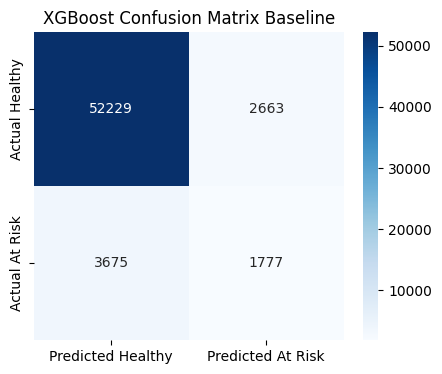

In [5]:
# General performance scores
y_preds = xgb_model.predict(X_test_scaled)
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_preds)
auc = roc_auc_score(y_test, y_probs)

print(f"\n=== BENCHMARK MATRIX PERFORMANCE RESULTS ===")
print(f"Global Pipeline Accuracy Score : {acc * 100:.2f}%")
print(f"Receiver ROC-AUC Performance Metric: {auc:.4f}")
print("\nDetailed Target Class Sub-Breakdown:")
print(classification_report(y_test, y_preds))

# Show confusion plot
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Healthy', 'Predicted At Risk'],
            yticklabels=['Actual Healthy', 'Actual At Risk'])
plt.title("XGBoost Confusion Matrix Baseline")
plt.show()

## Cell 6: Code (The Production Testing Sandbox Engine)

In [6]:
def run_patient_sandbox_diagnostic(raw_patient_features):
    """
    Accepts raw raw_patient_features input dictionary, maps it safely to historical dummy 
    schemas, scales numeric properties, and pushes out clear risk predictions.
    """
    # Create single-row DataFrame framework from inputs
    input_df = pd.DataFrame([raw_patient_features])
    
    # Isolate categorical vs numerical structures matching base data transformations
    input_encoded = pd.get_dummies(input_df, columns=[c for c in categorical_cols if c in input_df.columns])
    
    # Build complete execution row matrix tracking structural index constraints
    sandbox_row = pd.DataFrame(0.0, index=[0], columns=master_feature_columns)
    
    # Fill in metrics matched dynamically inside input properties
    for col in input_encoded.columns:
        if col in sandbox_row.columns:
            sandbox_row.loc[0, col] = float(input_encoded.loc[0, col])
            
    # Copy across missing continuous categorical flags matching identical raw base string patterns
    for col in master_feature_columns:
        if '_' in col:
            base_feature, val = col.split('_', 1)
            if base_feature in input_df.columns and str(input_df.loc[0, base_feature]) == val:
                sandbox_row.loc[0, col] = 1.0

    # Apply saved scaler constraints directly onto continuous numbers safely
    sandbox_row[numerical_cols] = scaler.transform(input_df[numerical_cols])
    
    # Process classification parameters
    risk_probability = xgb_model.predict_proba(sandbox_row)[:, 1][0]
    binary_label = "AT RISK (Heart Disease Warning Indicator)" if risk_probability >= 0.5 else "HEALTHY / LOW RISK"
    
    print("\n" + "="*50)
    print("           SANDBOX CLINICAL DIAGNOSTIC REPORT      ")
    print("="*50)
    print(f"Calculated Pathological Risk Probability : {risk_probability * 100:.2f}%")
    print(f"Assigned Diagnostic Category Label       : {binary_label}")
    print("="*50 + "\n")


# --------------------------------------------------------------------------
# MANUAL TESTING SPACE (Modify values in these dictionaries to test the sandbox!)
# --------------------------------------------------------------------------

# Example 1: High-Risk Profile Sample Data
high_risk_patient = {
    'AgeCategory': '80 or older', 'Sex': 'Male', 'Smoking': 'Yes', 'AlcoholDrinking': 'No',
    'Stroke': 'Yes', 'PhysicalHealth': 20.0, 'MentalHealth': 10.0, 'DiffWalking': 'Yes',
    'Diabetic': 'Yes', 'PhysicalActivity': 'No', 'GenHealth': 'Poor', 'SleepTime': 5.0,
    'Asthma': 'No', 'KidneyDisease': 'Yes', 'SkinCancer': 'No', 'BMI': 34.5
}

# Example 2: Low-Risk Profile Sample Data
low_risk_patient = {
    'AgeCategory': '25-29', 'Sex': 'Female', 'Smoking': 'No', 'AlcoholDrinking': 'No',
    'Stroke': 'No', 'PhysicalHealth': 0.0, 'MentalHealth': 2.0, 'DiffWalking': 'No',
    'Diabetic': 'No', 'PhysicalActivity': 'Yes', 'GenHealth': 'Excellent', 'SleepTime': 8.0,
    'Asthma': 'No', 'KidneyDisease': 'No', 'SkinCancer': 'No', 'BMI': 22.1
}

# Run the manual sandbox simulations
print("Testing Sandbox with a High-Risk patient case...")
run_patient_sandbox_diagnostic(high_risk_patient)

print("Testing Sandbox with a Low-Risk patient case...")
run_patient_sandbox_diagnostic(low_risk_patient)

Testing Sandbox with a High-Risk patient case...

           SANDBOX CLINICAL DIAGNOSTIC REPORT      
Calculated Pathological Risk Probability : 88.79%
Assigned Diagnostic Category Label       : AT RISK (Heart Disease Warning Indicator)

Testing Sandbox with a Low-Risk patient case...

           SANDBOX CLINICAL DIAGNOSTIC REPORT      
Calculated Pathological Risk Probability : 0.76%
Assigned Diagnostic Category Label       : HEALTHY / LOW RISK



In [7]:
import pickle

# Bundle the model and all preprocessing metadata into a single dictionary
model_artifacts = {
    'model': xgb_model,
    'scaler': scaler,
    'master_feature_columns': master_feature_columns,
    'categorical_cols': categorical_cols,
    'numerical_cols': numerical_cols
}

# Save the bundle to a file
model_filename = "xgboost_heart_disease_model.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f"Successfully saved all pipeline artifacts to '{model_filename}'!")

Successfully saved all pipeline artifacts to 'xgboost_heart_disease_model.pkl'!
